# BreastMNIST Ensemble Study, Evaluation and Plots

## Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_auc_score, precision_score, recall_score, f1_score,
                              average_precision_score, log_loss)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility of meta-learner
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## Configuration

In [2]:
DATASET = 'breastmnist'  # Change to: 'bloodmnist', 'breastmnist', 'dermamnist', 'organamnist'

# Dataset-specific configuration
DATASET_CONFIG = {
    'bloodmnist':   {'n_classes': 8,  'figure_number': 3},
    'breastmnist':  {'n_classes': 2,  'figure_number': 4},
    'dermamnist':   {'n_classes': 7,  'figure_number': 5},
    'organamnist':  {'n_classes': 11, 'figure_number': 6},
}

n_classes = DATASET_CONFIG[DATASET]['n_classes']
FIGURE_NUMBER = DATASET_CONFIG[DATASET]['figure_number']

INPUT_DIR = f"./{DATASET}_outputs"  
OUTPUT_DIR = f"./{DATASET}_results"  
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class names mapping
CLASS_NAMES_MAP = {
    'bloodmnist': ['basophil', 'eosinophil', 'erythroblast', 'immature granulocyte',
                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet'],
    'breastmnist': ['malignant', 'normal/benign'],
    'dermamnist': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
    'organamnist': ['bladder', 'femur-L', 'femur-R', 'heart', 'kidney-L', 'kidney-R',
                    'liver', 'lung-L', 'lung-R', 'pancreas', 'spleen']
}

CLASS_NAMES_MAP_4CM = {
    'bloodmnist': ['basophil', 'eosinophil', 'erythroblast', 'immature \ngranulocyte',
                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet'],
    'breastmnist': ['malignant', 'normal/benign'],
    'dermamnist': ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
    'organamnist': ['bladder', 'femur-L', 'femur-R', 'heart', 'kidney-L', 'kidney-R',
                    'liver', 'lung-L', 'lung-R', 'pancreas', 'spleen']
}
CLASS_NAMES = CLASS_NAMES_MAP[DATASET]
CLASS_NAMES_4CM = CLASS_NAMES_MAP_4CM[DATASET]

# Meta-learner hyperparameters
DROPOUT_META = 0.5
META_BATCH_SIZE = 16
META_EPOCHS = 50
META_PATIENCE = 5

print(f"Dataset: {DATASET}")
print(f"Number of classes: {n_classes}")
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset: breastmnist
Number of classes: 2
Input directory: ./breastmnist_outputs
Output directory: ./breastmnist_results


## Load Predictions and Ground Truth

In [3]:
import medmnist
from medmnist import INFO

INDIVIDUAL_MODELS = ['ConvNeXtBase', 'ViT-Base', 'EfficientNetV2M', 'InceptionResNetV2']

def get_or_create_labels(split, primary_name, alternate_names, input_dir, dataset):
    primary_path = f"{input_dir}/{primary_name}"
    if os.path.exists(primary_path):
        labels = np.load(primary_path).flatten()
        print(f"  Loaded {split} labels from {primary_name} ({len(labels)} samples)")
        return labels
    for fname in alternate_names:
        p = f"{input_dir}/{fname}"
        if os.path.exists(p):
            labels = np.load(p).flatten()
            np.save(primary_path, labels)
            print(f"  Loaded {split} labels from {fname} and saved as {primary_name}")
            return labels
    print(f"  {primary_name} not found - reconstructing from MedMNIST...")
    info = INFO[dataset]
    DataClass = getattr(medmnist, info['python_class'])
    data = DataClass(split=split, download=True, size=28)
    labels = data.labels.flatten()
    np.save(primary_path, labels)
    print(f"  Saved {primary_name} ({len(labels)} samples)")
    return labels


print("Loading predictions...")
test_preds = {}
val_preds = {}
for m in INDIVIDUAL_MODELS:
    test_preds[m] = np.load(f"{INPUT_DIR}/{m}_test_preds.npy")
    val_preds[m] = np.load(f"{INPUT_DIR}/{m}_val_preds.npy")
    print(f"  {m}: test {test_preds[m].shape}, val {val_preds[m].shape}")

print("\nChecking for NaN in predictions...")
nan_found = False
for m in INDIVIDUAL_MODELS:
    mask_test = np.any(np.isnan(test_preds[m]), axis=1)
    mask_val = np.any(np.isnan(val_preds[m]), axis=1)
    if mask_test.sum() > 0:
        print(f"  Repairing {mask_test.sum()} NaN row(s) in {m} test predictions")
        test_preds[m][mask_test] = 1.0 / n_classes
        nan_found = True
    if mask_val.sum() > 0:
        print(f"  Repairing {mask_val.sum()} NaN row(s) in {m} val predictions")
        val_preds[m][mask_val] = 1.0 / n_classes
        nan_found = True
if not nan_found:
    print("  All predictions clean.")

print(f"\nLoading ground truth labels for {DATASET}...")
y_true_flat = get_or_create_labels(
    'test', 'y_true_flat.npy', ['y_test_true.npy'], INPUT_DIR, DATASET
)
y_val_flat = get_or_create_labels(
    'val', 'y_val_flat.npy', ['y_val_true.npy'], INPUT_DIR, DATASET
)

y_true_cat = to_categorical(y_true_flat, n_classes)
y_val_cat = to_categorical(y_val_flat, n_classes)

print(f"\nTest samples: {len(y_true_flat)}")
print(f"Val samples:  {len(y_val_flat)}")

Loading predictions...
  ConvNeXtBase: test (156, 2), val (78, 2)
  ViT-Base: test (156, 2), val (78, 2)
  EfficientNetV2M: test (156, 2), val (78, 2)
  InceptionResNetV2: test (156, 2), val (78, 2)

Checking for NaN in predictions...
  All predictions clean.

Loading ground truth labels for breastmnist...
  Loaded test labels from y_true_flat.npy (156 samples)
  Loaded val labels from y_val_flat.npy (78 samples)

Test samples: 156
Val samples:  78


## Soft Voting Ensemble

In [4]:
print("="*70)
print("SOFT VOTING ENSEMBLE")
print("="*70)

soft_voting_probs = np.mean(np.array(list(test_preds.values())), axis=0)
np.save(f"{OUTPUT_DIR}/SoftVoting_test_preds.npy", soft_voting_probs)

acc = accuracy_score(y_true_flat, np.argmax(soft_voting_probs, axis=1))
print(f"Soft Voting Accuracy: {acc:.4f}")
print(f"Saved to: {OUTPUT_DIR}/SoftVoting_test_preds.npy")

SOFT VOTING ENSEMBLE
Soft Voting Accuracy: 0.9295
Saved to: ./breastmnist_results/SoftVoting_test_preds.npy


## Rigorous Stacking Ensemble

In [5]:
print("="*70)
print("RIGOROUS STACKING ENSEMBLE")
print("="*70)

# Build meta-training input from validation predictions
X_meta_train = np.concatenate([val_preds[m] for m in INDIVIDUAL_MODELS], axis=1)
X_meta_test = np.concatenate([test_preds[m] for m in INDIVIDUAL_MODELS], axis=1)

print(f"Meta-train shape: {X_meta_train.shape}")
print(f"Meta-test shape: {X_meta_test.shape}")

def build_meta_learner(input_dim, n_classes):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dropout(DROPOUT_META)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs, name='Meta_Learner')

meta_model = build_meta_learner(X_meta_train.shape[1], n_classes)
meta_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

meta_model.fit(X_meta_train, y_val_cat,
               epochs=META_EPOCHS, batch_size=META_BATCH_SIZE,
               validation_split=0.1,
               callbacks=[callbacks.EarlyStopping(patience=META_PATIENCE, restore_best_weights=True)],
               verbose=1)

meta_model.save(f"{OUTPUT_DIR}/MetaLearner_{DATASET}.keras")
stacking_probs = meta_model.predict(X_meta_test, verbose=0)
np.save(f"{OUTPUT_DIR}/RigorousStacking_test_preds.npy", stacking_probs)

acc = accuracy_score(y_true_flat, np.argmax(stacking_probs, axis=1))
print(f"\nRigorous Stacking Accuracy: {acc:.4f}")
print(f"Saved to: {OUTPUT_DIR}/RigorousStacking_test_preds.npy")

RIGOROUS STACKING ENSEMBLE
Meta-train shape: (78, 8)
Meta-test shape: (156, 8)
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6286 - loss: 0.6607 - val_accuracy: 1.0000 - val_loss: 0.5448
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8857 - loss: 0.5730 - val_accuracy: 1.0000 - val_loss: 0.4883
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8857 - loss: 0.5267 - val_accuracy: 1.0000 - val_loss: 0.4414
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9286 - loss: 0.4742 - val_accuracy: 1.0000 - val_loss: 0.4015
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9286 - loss: 0.4450 - val_accuracy: 1.0000 - val_loss: 0.3649
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9571 - loss: 0.4096 - val_accuracy: 1.0000 - val_loss: 0.3316
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9571 - loss: 0.3631 - val_accuracy: 1.0000 - val_loss: 0.2972
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/st

## Analysis Helper Functions

In [6]:
def print_confusion_matrix_table(cm, class_names, model_name):
    """Prints confusion matrix as a labeled pandas DataFrame."""
    cm_df = pd.DataFrame(cm,
                         index=[f"True_{c}" for c in class_names],
                         columns=[f"Pred_{c}" for c in class_names])
    print(f"\n--- {model_name} Confusion Matrix (Table) ---")
    print(cm_df.to_string())
    
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print(f"\n--- Per-Class Recall ---")
    for i, c in enumerate(class_names):
        print(f"  Class {i} ({c}): {per_class_acc[i]:.4f} ({cm[i, i]}/{cm[i].sum()})")
    return cm_df


def analyze_entropy_peaks(entropy_correct, entropy_wrong, model_name,
                          n_points=1000):
    """
    Returns the single highest peak (mode) for correct and incorrect distributions.
    """
    if len(entropy_correct) < 2 or len(entropy_wrong) < 1:
        print(f"\n--- {model_name} ---\nInsufficient data for KDE")
        return None
    
    x_min = 0
    x_max = max(entropy_correct.max(), entropy_wrong.max()) + 0.1
    x_grid = np.linspace(x_min, x_max, n_points)
    
    # KDE for correct distribution - take global maximum
    kde_correct = gaussian_kde(entropy_correct)
    density_correct = kde_correct(x_grid)
    peak_correct_idx = int(np.argmax(density_correct))
    peak_correct_x = float(x_grid[peak_correct_idx])
    peak_correct_y = float(density_correct[peak_correct_idx])
    
    # KDE for wrong distribution - take global maximum
    if len(entropy_wrong) >= 2:
        kde_wrong = gaussian_kde(entropy_wrong)
        density_wrong = kde_wrong(x_grid)
        peak_wrong_idx = int(np.argmax(density_wrong))
        peak_wrong_x = float(x_grid[peak_wrong_idx])
        peak_wrong_y = float(density_wrong[peak_wrong_idx])
    else:
        # Edge case: single wrong sample
        density_wrong = np.zeros(n_points)
        peak_wrong_x = float(entropy_wrong[0])
        peak_wrong_y = 0.0
    
    print(f"\n--- {model_name} Entropy Distribution Analysis ---")
    print(f"Correct: n={len(entropy_correct)}, "
          f"mean={entropy_correct.mean():.4f}, "
          f"median={np.median(entropy_correct):.4f}, "
          f"std={entropy_correct.std():.4f}")
    print(f"Wrong:   n={len(entropy_wrong)}, "
          f"mean={entropy_wrong.mean():.4f}, "
          f"median={np.median(entropy_wrong):.4f}, "
          f"std={entropy_wrong.std():.4f}")
    
    print(f"\nHighest correct peak: entropy={peak_correct_x:.4f}, height={peak_correct_y:.4f}")
    print(f"Highest wrong peak:   entropy={peak_wrong_x:.4f}, height={peak_wrong_y:.4f}")
    
    return {
        'x_grid': x_grid.tolist(),
        'density_correct': density_correct.tolist(),
        'density_wrong': density_wrong.tolist(),
        'peaks_correct_x': [peak_correct_x],
        'peaks_correct_y': [peak_correct_y],
        'peaks_wrong_x': [peak_wrong_x],
        'peaks_wrong_y': [peak_wrong_y],
    }


def analyze_reliability_pairs(probs, y_pred, y_true, model_name, n_bins=10):
    is_correct = (y_pred == y_true).astype(int)
    pred_conf = np.max(probs, axis=1)
    
    prob_true, prob_pred = calibration_curve(is_correct, pred_conf, n_bins=n_bins, strategy='quantile')
    
    bins = np.quantile(pred_conf, np.linspace(0, 1, n_bins+1))
    bin_counts = []
    for i in range(len(bins)-1):
        mask = (pred_conf >= bins[i]) & (pred_conf <= bins[i+1])
        bin_counts.append(int(mask.sum()))
    
    print(f"\n--- {model_name} Reliability Diagram (Numerical) ---")
    print(f"{'Bin':<5} {'Confidence':<15} {'Accuracy':<15} {'Gap':<15} {'n_samples':<10}")
    print("-" * 65)
    for i in range(len(prob_pred)):
        gap = prob_pred[i] - prob_true[i]
        n = bin_counts[i] if i < len(bin_counts) else 0
        print(f"{i+1:<5} {prob_pred[i]:<15.4f} {prob_true[i]:<15.4f} {gap:<15.4f} {n:<10}")
    
    valid_counts = bin_counts[:len(prob_pred)]
    if sum(valid_counts) > 0:
        ece = np.sum(np.abs(np.array(prob_pred) - np.array(prob_true)) *
                     np.array(valid_counts) / sum(valid_counts))
    else:
        ece = 0
    print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
    
    return {
        'confidence': prob_pred.tolist(),
        'accuracy': prob_true.tolist(),
        'gap': (prob_pred - prob_true).tolist(),
        'bin_counts': bin_counts,
        'ece': float(ece)
    }


def compute_all_metrics(probs, y_true_flat, y_true_cat, model_name):
    y_pred = np.argmax(probs, axis=1)
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true_flat, y_pred),
        'AUC_macro': roc_auc_score(y_true_cat, probs, multi_class='ovr', average='macro'),
        'AUC_weighted': roc_auc_score(y_true_cat, probs, multi_class='ovr', average='weighted'),
        'Precision_macro': precision_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'Precision_weighted': precision_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'Recall_macro': recall_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'Recall_weighted': recall_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'F1_macro': f1_score(y_true_flat, y_pred, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_true_flat, y_pred, average='weighted', zero_division=0),
        'PR_AUC_macro': average_precision_score(y_true_cat, probs, average='macro'),
        'PR_AUC_weighted': average_precision_score(y_true_cat, probs, average='weighted'),
        'Log_Loss': log_loss(y_true_cat, probs)
    }

##  Master Evaluation Function

In [7]:
def to_json_safe(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj


def evaluate_model(probs, y_true_flat, y_true_cat, model_name, class_names, class_names_4cm, color='Blues'):
    print(f"\n{'='*70}\nEVALUATION: {model_name}\n{'='*70}")
    
    y_pred = np.argmax(probs, axis=1)
    
    # 1. Metrics
    metrics = compute_all_metrics(probs, y_true_flat, y_true_cat, model_name)
    print("\n--- Comprehensive Metrics ---")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k}: {v:.4f}")
    
    # 2. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_true_flat, y_pred, target_names=class_names, digits=4))
    
    # 3. Confusion Matrix
    cm = confusion_matrix(y_true_flat, y_pred)
    print_confusion_matrix_table(cm, class_names, model_name)
    
    # 4. Entropy Analysis 
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    correct_mask = (y_pred == y_true_flat)
    entropy_analysis = analyze_entropy_peaks(
        entropy[correct_mask], entropy[~correct_mask], model_name
    )
    
    # 5. Reliability Analysis
    reliability = analyze_reliability_pairs(probs, y_pred, y_true_flat, model_name)
    
    # 6. Diagnostic Plots WITH peak markers shown
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=axes[0],
                xticklabels=class_names_4cm, yticklabels=class_names_4cm)
    axes[0].set_title(f'{model_name} CM (Acc: {metrics["Accuracy"]:.2%})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', labelsize=6)
    axes[0].tick_params(axis='y', labelsize=6)
    plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center', rotation_mode='anchor')
    
    # Entropy Distribution WITH peak markers
    sns.kdeplot(entropy[correct_mask], label=f'Correct (n={correct_mask.sum()})',
                fill=True, color='#2166AC', ax=axes[1])
    sns.kdeplot(entropy[~correct_mask], label=f'Wrong (n={(~correct_mask).sum()})',
                fill=True, color='#D97B00', ax=axes[1])
    
    if entropy_analysis:
        for px, py in list(zip(entropy_analysis['peaks_correct_x'],
                                entropy_analysis['peaks_correct_y']))[:3]:
            axes[1].axvline(px, color='#2166AC', linestyle=':', alpha=0.6)
            axes[1].annotate(f'{px:.2f}\nh={py:.2f}', xy=(px, py),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, color='#2166AC')
        for px, py in list(zip(entropy_analysis['peaks_wrong_x'],
                                entropy_analysis['peaks_wrong_y']))[:3]:
            axes[1].axvline(px, color='#D97B00', linestyle=':', alpha=0.6)
            axes[1].annotate(f'{px:.2f}\nh={py:.2f}', xy=(px, py),
                           xytext=(5, -15), textcoords='offset points',
                           fontsize=8, color='#D97B00')
    
    axes[1].set_title(f'{model_name} Entropy')
    axes[1].set_xlabel('Shannon Entropy')
    axes[1].legend()
    
    # Reliability Diagram
    axes[2].plot(reliability['confidence'], reliability['accuracy'],
                 marker='o', label=model_name, color='purple')
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
    axes[2].set_title(f'{model_name} Reliability (ECE={reliability["ece"]:.4f})')
    axes[2].set_xlabel('Confidence')
    axes[2].set_ylabel('Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{model_name}_evaluation.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save results
    results = {
        'metrics': {k: to_json_safe(v) for k, v in metrics.items()},
        'confusion_matrix': cm.tolist(),
        'entropy_analysis': entropy_analysis,
        'reliability': reliability
    }
    
    with open(f"{OUTPUT_DIR}/{model_name}_results.json", 'w') as f:
        json.dump(results, f, indent=2, default=to_json_safe)
    
    return results

## Evaluate All Models


EVALUATION: ConvNeXtBase

--- Comprehensive Metrics ---
  Accuracy: 0.9103
  AUC_macro: 0.9244
  AUC_weighted: 0.9244
  Precision_macro: 0.8823
  Precision_weighted: 0.9119
  Recall_macro: 0.8935
  Recall_weighted: 0.9103
  F1_macro: 0.8876
  F1_weighted: 0.9109
  PR_AUC_macro: 0.9178
  PR_AUC_weighted: 0.9368
  Log_Loss: 0.3119

--- Classification Report ---
               precision    recall  f1-score   support

    malignant     0.8182    0.8571    0.8372        42
normal/benign     0.9464    0.9298    0.9381       114

     accuracy                         0.9103       156
    macro avg     0.8823    0.8935    0.8876       156
 weighted avg     0.9119    0.9103    0.9109       156


--- ConvNeXtBase Confusion Matrix (Table) ---
                    Pred_malignant  Pred_normal/benign
True_malignant                  36                   6
True_normal/benign               8                 106

--- Per-Class Recall ---
  Class 0 (malignant): 0.8571 (36/42)
  Class 1 (normal/benign): 0

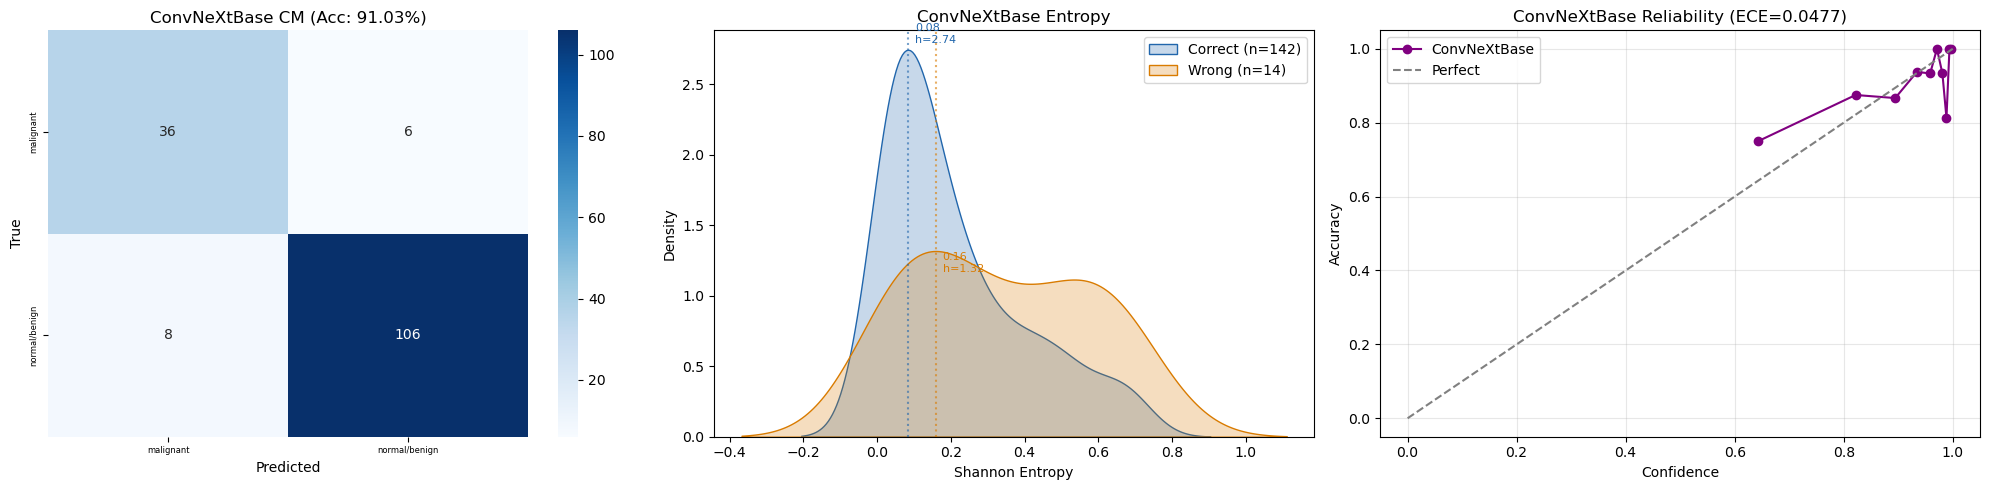


EVALUATION: ViT-Base

--- Comprehensive Metrics ---
  Accuracy: 0.9167
  AUC_macro: 0.9307
  AUC_weighted: 0.9307
  Precision_macro: 0.8964
  Precision_weighted: 0.9161
  Recall_macro: 0.8904
  Recall_weighted: 0.9167
  F1_macro: 0.8933
  F1_weighted: 0.9163
  PR_AUC_macro: 0.9302
  PR_AUC_weighted: 0.9462
  Log_Loss: 0.2939

--- Classification Report ---
               precision    recall  f1-score   support

    malignant     0.8537    0.8333    0.8434        42
normal/benign     0.9391    0.9474    0.9432       114

     accuracy                         0.9167       156
    macro avg     0.8964    0.8904    0.8933       156
 weighted avg     0.9161    0.9167    0.9163       156


--- ViT-Base Confusion Matrix (Table) ---
                    Pred_malignant  Pred_normal/benign
True_malignant                  35                   7
True_normal/benign               6                 108

--- Per-Class Recall ---
  Class 0 (malignant): 0.8333 (35/42)
  Class 1 (normal/benign): 0.9474 (1

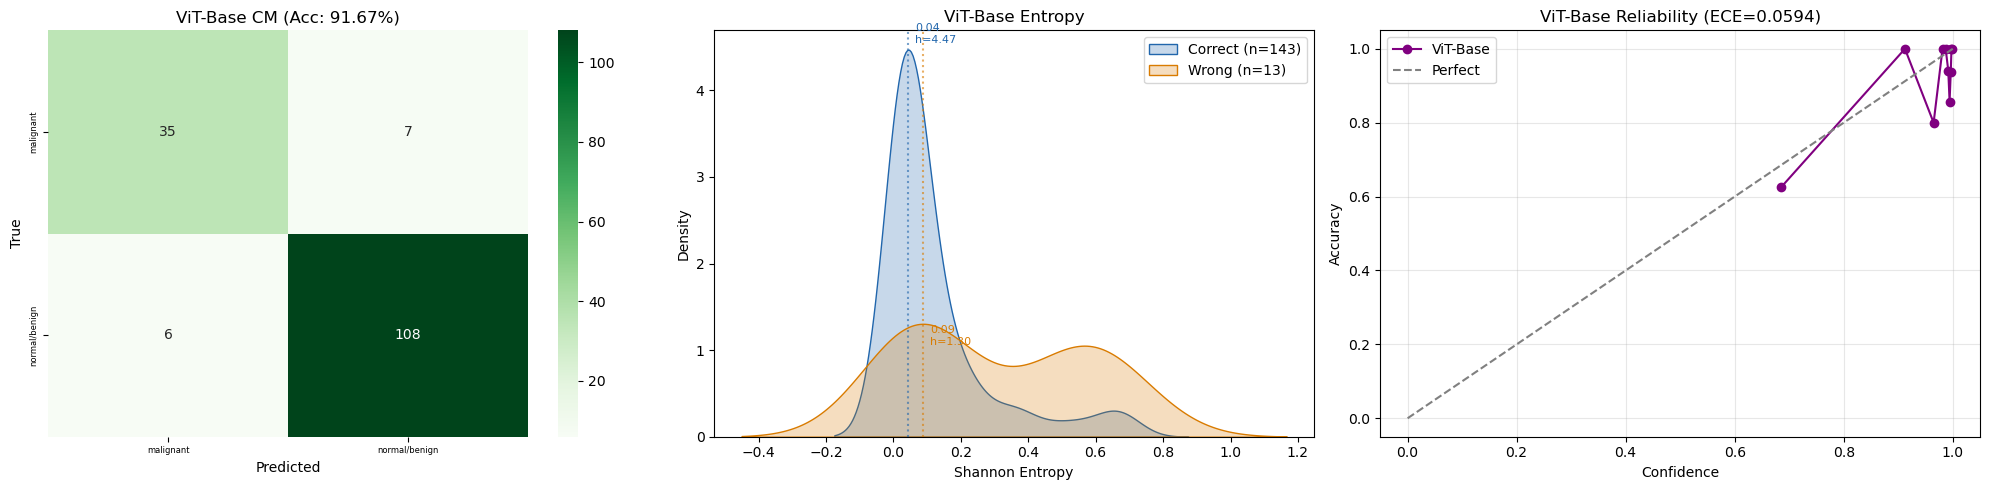


EVALUATION: EfficientNetV2M

--- Comprehensive Metrics ---
  Accuracy: 0.8718
  AUC_macro: 0.8966
  AUC_weighted: 0.8966
  Precision_macro: 0.8401
  Precision_weighted: 0.8701
  Recall_macro: 0.8296
  Recall_weighted: 0.8718
  F1_macro: 0.8346
  F1_weighted: 0.8708
  PR_AUC_macro: 0.8766
  PR_AUC_weighted: 0.9113
  Log_Loss: 0.3813

--- Classification Report ---
               precision    recall  f1-score   support

    malignant     0.7750    0.7381    0.7561        42
normal/benign     0.9052    0.9211    0.9130       114

     accuracy                         0.8718       156
    macro avg     0.8401    0.8296    0.8346       156
 weighted avg     0.8701    0.8718    0.8708       156


--- EfficientNetV2M Confusion Matrix (Table) ---
                    Pred_malignant  Pred_normal/benign
True_malignant                  31                  11
True_normal/benign               9                 105

--- Per-Class Recall ---
  Class 0 (malignant): 0.7381 (31/42)
  Class 1 (normal/beni

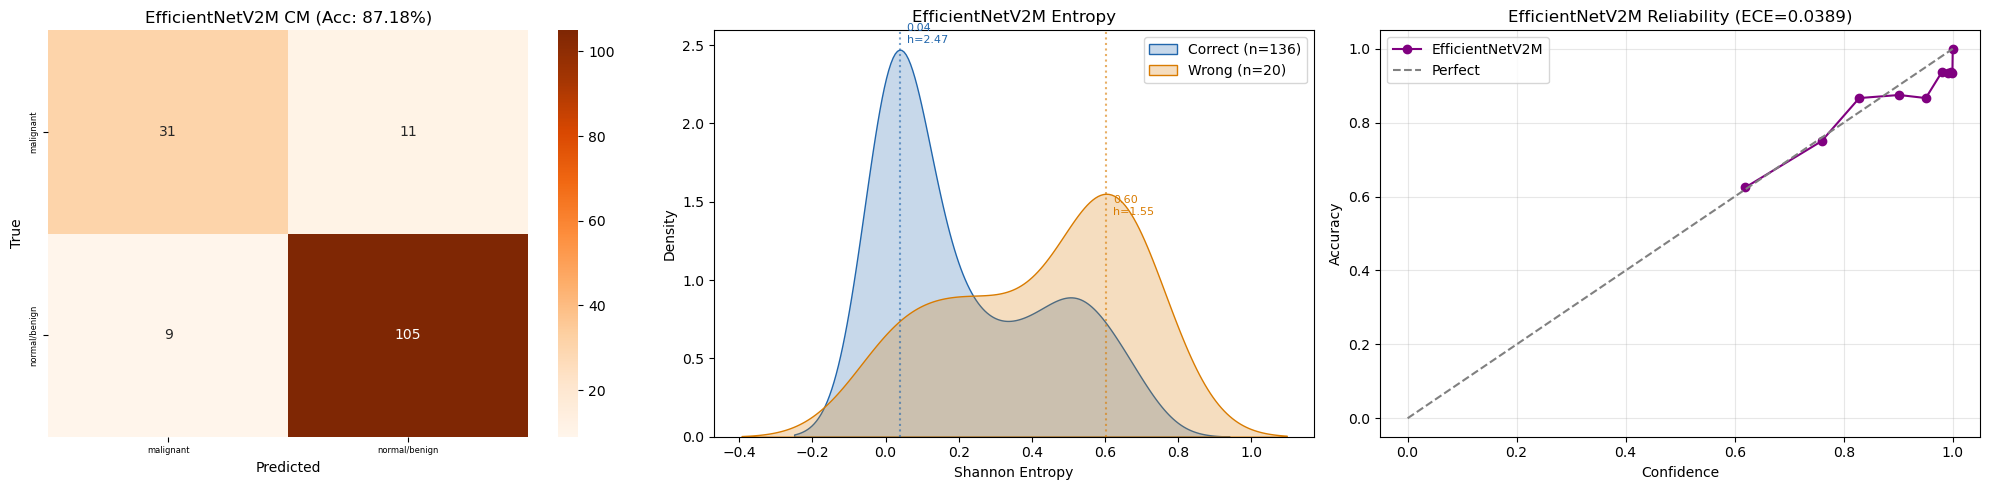


EVALUATION: InceptionResNetV2

--- Comprehensive Metrics ---
  Accuracy: 0.8910
  AUC_macro: 0.8996
  AUC_weighted: 0.8997
  Precision_macro: 0.8600
  Precision_weighted: 0.8919
  Recall_macro: 0.8653
  Recall_weighted: 0.8910
  F1_macro: 0.8626
  F1_weighted: 0.8914
  PR_AUC_macro: 0.8812
  PR_AUC_weighted: 0.9045
  Log_Loss: 0.5173

--- Classification Report ---
               precision    recall  f1-score   support

    malignant     0.7907    0.8095    0.8000        42
normal/benign     0.9292    0.9211    0.9251       114

     accuracy                         0.8910       156
    macro avg     0.8600    0.8653    0.8626       156
 weighted avg     0.8919    0.8910    0.8914       156


--- InceptionResNetV2 Confusion Matrix (Table) ---
                    Pred_malignant  Pred_normal/benign
True_malignant                  34                   8
True_normal/benign               9                 105

--- Per-Class Recall ---
  Class 0 (malignant): 0.8095 (34/42)
  Class 1 (normal/

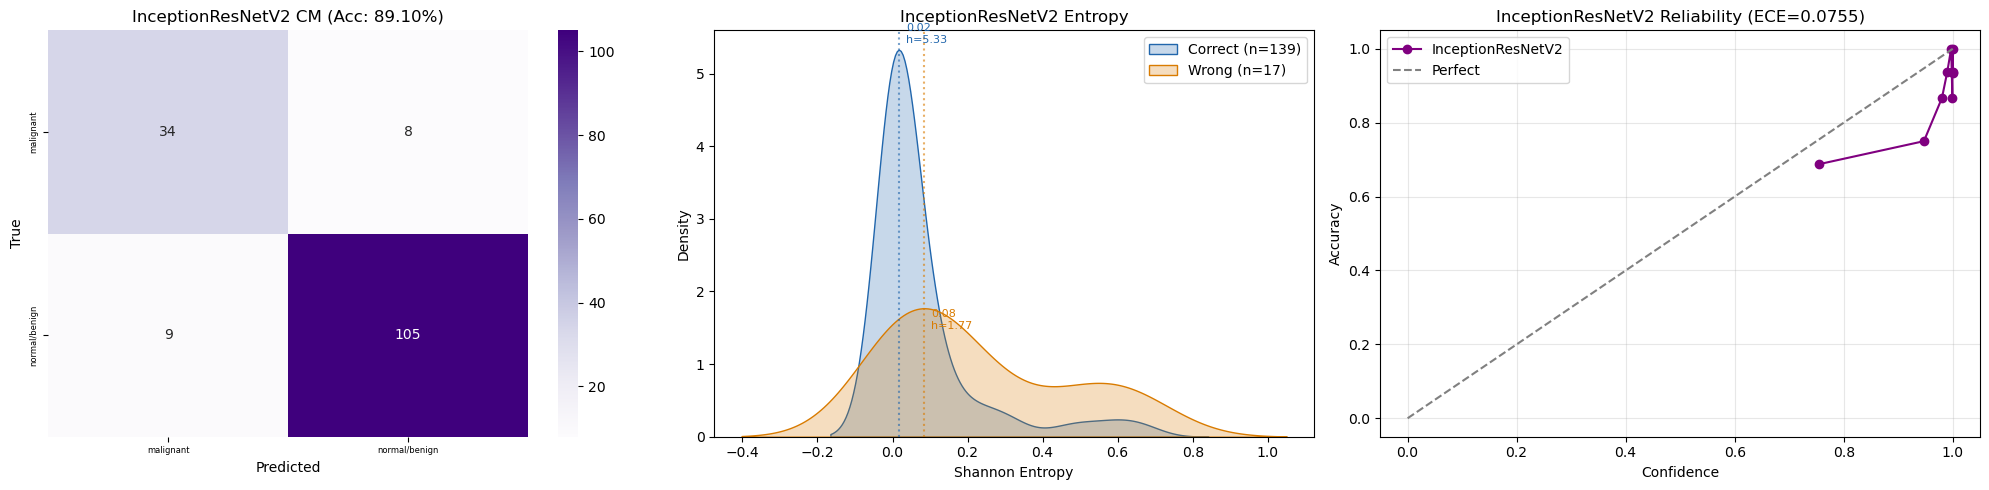


EVALUATION: SoftVoting

--- Comprehensive Metrics ---
  Accuracy: 0.9295
  AUC_macro: 0.9432
  AUC_weighted: 0.9432
  Precision_macro: 0.9129
  Precision_weighted: 0.9290
  Recall_macro: 0.9066
  Recall_weighted: 0.9295
  F1_macro: 0.9097
  F1_weighted: 0.9292
  PR_AUC_macro: 0.9385
  PR_AUC_weighted: 0.9534
  Log_Loss: 0.2386

--- Classification Report ---
               precision    recall  f1-score   support

    malignant     0.8780    0.8571    0.8675        42
normal/benign     0.9478    0.9561    0.9520       114

     accuracy                         0.9295       156
    macro avg     0.9129    0.9066    0.9097       156
 weighted avg     0.9290    0.9295    0.9292       156


--- SoftVoting Confusion Matrix (Table) ---
                    Pred_malignant  Pred_normal/benign
True_malignant                  36                   6
True_normal/benign               5                 109

--- Per-Class Recall ---
  Class 0 (malignant): 0.8571 (36/42)
  Class 1 (normal/benign): 0.956

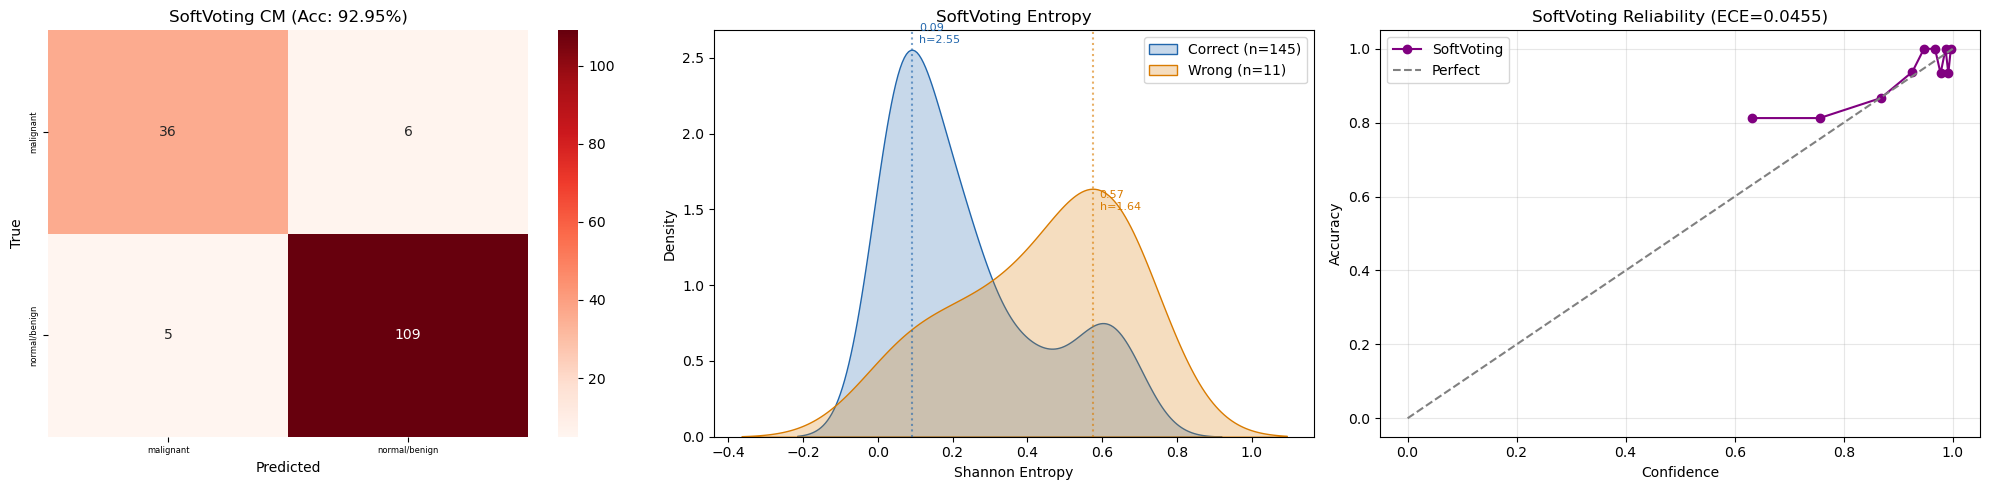


EVALUATION: RigorousStacking

--- Comprehensive Metrics ---
  Accuracy: 0.9103
  AUC_macro: 0.9403
  AUC_weighted: 0.9403
  Precision_macro: 0.9028
  Precision_weighted: 0.9092
  Recall_macro: 0.8634
  Recall_weighted: 0.9103
  F1_macro: 0.8803
  F1_weighted: 0.9080
  PR_AUC_macro: 0.9363
  PR_AUC_weighted: 0.9509
  Log_Loss: 0.3171

--- Classification Report ---
               precision    recall  f1-score   support

    malignant     0.8889    0.7619    0.8205        42
normal/benign     0.9167    0.9649    0.9402       114

     accuracy                         0.9103       156
    macro avg     0.9028    0.8634    0.8803       156
 weighted avg     0.9092    0.9103    0.9080       156


--- RigorousStacking Confusion Matrix (Table) ---
                    Pred_malignant  Pred_normal/benign
True_malignant                  32                  10
True_normal/benign               4                 110

--- Per-Class Recall ---
  Class 0 (malignant): 0.7619 (32/42)
  Class 1 (normal/be

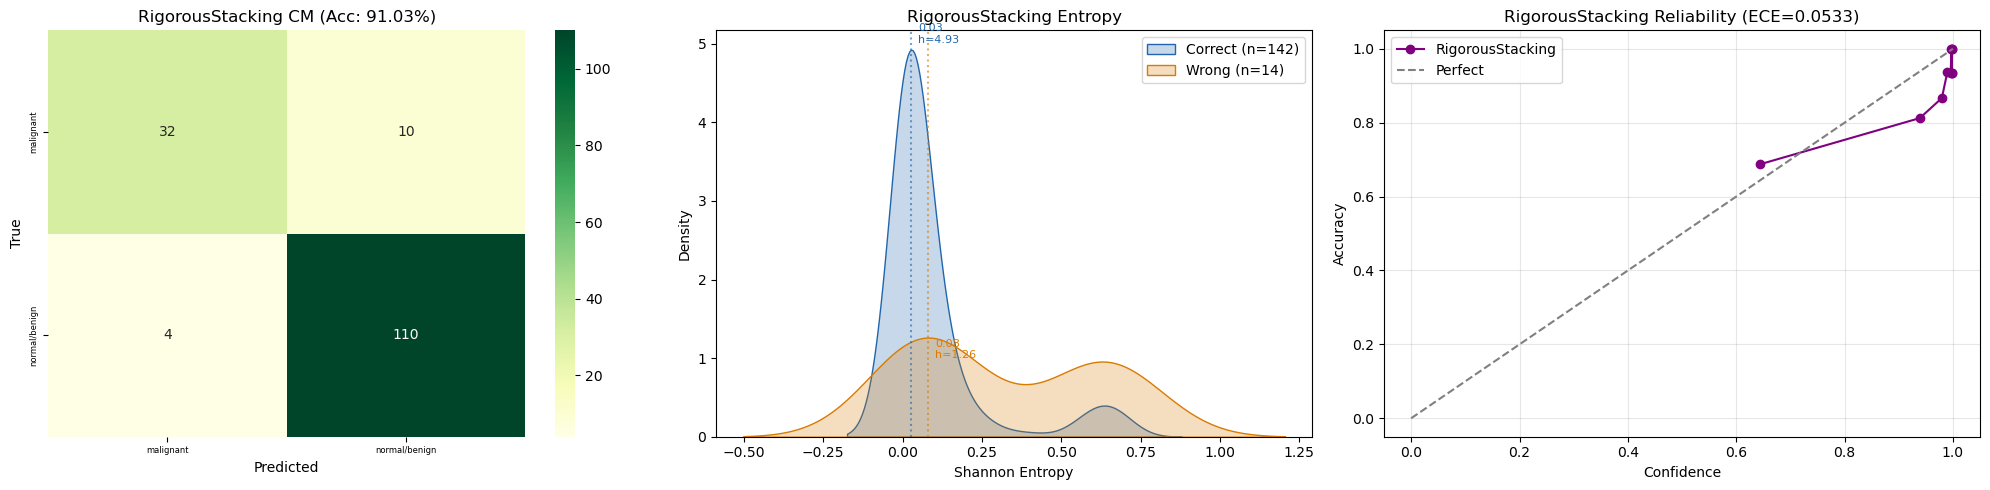

In [8]:
COLORS = {
    'ConvNeXtBase': 'Blues', 'ViT-Base': 'Greens',
    'EfficientNetV2M': 'Oranges', 'InceptionResNetV2': 'Purples',
    'SoftVoting': 'Reds', 'RigorousStacking': 'YlGn'
}

all_results = {}
all_metrics_list = []

# Build complete predictions dict
all_probs = dict(test_preds)
all_probs['SoftVoting'] = soft_voting_probs
all_probs['RigorousStacking'] = stacking_probs

for model_name in INDIVIDUAL_MODELS + ['SoftVoting', 'RigorousStacking']:
    res = evaluate_model(all_probs[model_name], y_true_flat, y_true_cat,
                         model_name, CLASS_NAMES, CLASS_NAMES_4CM, color=COLORS[model_name])
    all_results[model_name] = res
    all_metrics_list.append(res['metrics'])

## Summary Tables

In [9]:
print(f"\n{'='*90}\nFINAL COMPARISON: {DATASET.upper()}\n{'='*90}")

summary_df = pd.DataFrame(all_metrics_list)
print("\n--- Full Metrics Comparison ---")
print(summary_df.to_string(index=False))

summary_df.to_csv(f"{OUTPUT_DIR}/{DATASET}_summary_metrics.csv", index=False)

compact = summary_df[['Model', 'Accuracy', 'AUC_macro', 'F1_macro',
                       'Precision_macro', 'Recall_macro', 'PR_AUC_macro']].copy()
compact.columns = ['Model', 'Accuracy', 'AUC', 'F1', 'Precision', 'Recall', 'PR-AUC']
print("\n--- Compact Table for Paper ---")
print(compact.to_string(index=False))
compact.to_csv(f"{OUTPUT_DIR}/{DATASET}_compact_metrics.csv", index=False)


FINAL COMPARISON: BREASTMNIST

--- Full Metrics Comparison ---
            Model  Accuracy  AUC_macro  AUC_weighted  Precision_macro  Precision_weighted  Recall_macro  Recall_weighted  F1_macro  F1_weighted  PR_AUC_macro  PR_AUC_weighted  Log_Loss
     ConvNeXtBase  0.910256   0.924394      0.924394         0.882305            0.911901      0.893484         0.910256  0.887631     0.910903      0.917815         0.936768  0.311870
         ViT-Base  0.916667   0.930660      0.930660         0.896394            0.916119      0.890351         0.916667  0.893302     0.916347      0.930151         0.946165  0.293904
  EfficientNetV2M  0.871795   0.896617      0.896617         0.840086            0.870126      0.829574         0.871795  0.834571     0.870789      0.876629         0.911306  0.381288
InceptionResNetV2  0.891026   0.899593      0.899713         0.859951            0.891913      0.865288         0.891026  0.862555     0.891427      0.881188         0.904514  0.517317
       Soft

## Publication Figure

In [10]:

ROW_LETTERS = list("abcdef")
CORRECT_COLOR_FIG = "#2166AC"
WRONG_COLOR_FIG = "#D97B00"

MODELS_FIG = [
    ("ConvNeXtBase",      "ConvNeXt-Base",      "Oranges", "darkorange"),
    ("ViT-Base",          "ViT-Base",           "Oranges", "darkorange"),
    ("EfficientNetV2M",   "EfficientNetV2-M",   "Oranges", "darkorange"),
    ("InceptionResNetV2", "InceptionResNetV2",  "Oranges", "darkorange"),
    ("SoftVoting",        "Soft Voting",        "Blues",   "#2166AC"),
    ("RigorousStacking",  "Rigorous Stacking",  "Greens",  "#1B7837"),
]

SHOW_PEAK_MARKERS = False  # Set True to add peak lines on entropy plots in pub figure


def plot_row_pub(fig, gs_row, model_key, cmap, line_color, row_idx, font_scale=1.0):
    probs = all_probs[model_key]
    y_pred_row = np.argmax(probs, axis=1)
    acc = accuracy_score(y_true_flat, y_pred_row)
    letter = ROW_LETTERS[row_idx]

    # Panel (1): Confusion Matrix
    ax0 = fig.add_subplot(gs_row[0])
    cm = confusion_matrix(y_true_flat, y_pred_row)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax0, cbar=False,
                annot_kws={"size": 5.0 * font_scale}, linewidths=0.08,
                xticklabels=np.arange(n_classes), yticklabels=np.arange(n_classes))
    ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)
    ax0.set_xlabel("Predicted Label")
    ax0.set_ylabel("True Label")
    ax0.tick_params(axis="both", pad=1)
    ax0.set_title(f"{letter}(1)   Acc = {acc:.2%}",
                  fontsize=7 * font_scale, fontweight="bold", loc="left", pad=3)

    # Panel (2): Entropy Distribution (with optional peak markers)
    ax1 = fig.add_subplot(gs_row[1])
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    correct = (y_pred_row == y_true_flat)
    sns.kdeplot(entropy[correct], fill=True, color=CORRECT_COLOR_FIG,
                alpha=0.55, ax=ax1, label="Correct", linewidth=0.6)
    sns.kdeplot(entropy[~correct], fill=True, color=WRONG_COLOR_FIG,
                alpha=0.55, ax=ax1, label="Incorrect", linewidth=0.6)
    
    if SHOW_PEAK_MARKERS and (~correct).sum() > 0:
        # Use the FIXED peak detection for visualization
        analysis = analyze_entropy_peaks(entropy[correct], entropy[~correct],
                                         f"Fig_{model_key}", n_points=500)
        if analysis:
            # Mark top peak only for each distribution to keep figure clean
            if analysis['peaks_correct_x']:
                ax1.axvline(analysis['peaks_correct_x'][0], color=CORRECT_COLOR_FIG,
                           linestyle=':', alpha=0.6, linewidth=0.5)
            if analysis['peaks_wrong_x']:
                ax1.axvline(analysis['peaks_wrong_x'][0], color=WRONG_COLOR_FIG,
                           linestyle=':', alpha=0.6, linewidth=0.5)
    
    ax1.set_xlabel("Entropy")
    ax1.set_ylabel("Density")
    ax1.legend(loc="upper right", frameon=False)
    ax1.tick_params(axis="both", pad=1)
    for spine in ax1.spines.values():
        spine.set_linewidth(0.4)
    ax1.set_title(f"{letter}(2)", fontsize=7 * font_scale,
                  fontweight="bold", loc="left", pad=3)

    # Panel (3): Reliability Diagram
    ax2 = fig.add_subplot(gs_row[2])
    is_correct = correct.astype(int)
    conf = np.max(probs, axis=1)
    p_true, p_pred = calibration_curve(is_correct, conf, n_bins=10, strategy="quantile")
    ax2.plot(p_pred, p_true, marker="o", markersize=1.5,
             lw=0.7, color=line_color, clip_on=False)
    ax2.plot([0, 1], [0, 1], "--", color="gray", lw=0.6)
    ax2.set_xlabel("Confidence")
    ax2.set_ylabel("Accuracy")
    ax2.set_xlim(-0.05, 1.05)
    ax2.set_ylim(-0.05, 1.05)
    ax2.tick_params(axis="both", pad=1)
    for spine in ax2.spines.values():
        spine.set_linewidth(0.4)
    ax2.set_title(f"{letter}(3)", fontsize=7 * font_scale,
                  fontweight="bold", loc="left", pad=3)


def generate_publication_figure(output_format='png', dpi=1200):
    if output_format == 'png':
        fig_w, fig_h = 6.85, 8.94
        font_scale = 1.0
        font_size = 7
    else:
        fig_w, fig_h = 18, 23.5
        font_scale = 1.6
        font_size = 11
    
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size - 0.5,
        "xtick.labelsize": font_size - 1.5,
        "ytick.labelsize": font_size - 1.5,
        "legend.fontsize": font_size - 1.5,
        "axes.linewidth": 0.4 * font_scale,
        "xtick.major.width": 0.4 * font_scale,
        "ytick.major.width": 0.4 * font_scale,
    })
    
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    gs_outer = gridspec.GridSpec(
        6, 1, figure=fig,
        hspace=0.55 if output_format == 'png' else 0.35,
        top=0.98, bottom=0.03 if output_format == 'png' else 0.02,
        left=0.10 if output_format == 'png' else 0.07,
        right=0.98
    )
    
    for i, (m_key, _, cmap, color) in enumerate(MODELS_FIG):
        gs_inner = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[i], wspace=0.28)
        plot_row_pub(fig, gs_inner, m_key, cmap, color, i, font_scale)
    
    ext = 'png' if output_format == 'png' else 'tif'
    output_path = f"{OUTPUT_DIR}/Fig{FIGURE_NUMBER}.{ext}"
    plt.savefig(output_path, bbox_inches="tight",
                pad_inches=0.05 if output_format == 'png' else 0.1,
                dpi=dpi, format=output_format,
                metadata={"Software": "matplotlib"} if output_format == 'png' else None)
    plt.close(fig)
    print(f"Saved {output_path}")
    return output_path

png_path = generate_publication_figure(output_format='png', dpi=1200)
tiff_path = generate_publication_figure(output_format='tiff', dpi=600)

print(f"\n✓ Publication figures:")
print(f"  PNG (1200 DPI): {png_path}")
print(f"  TIFF (600 DPI): {tiff_path}")

Saved ./breastmnist_results/Fig4.png
Saved ./breastmnist_results/Fig4.tif

✓ Publication figures:
  PNG (1200 DPI): ./breastmnist_results/Fig4.png
  TIFF (600 DPI): ./breastmnist_results/Fig4.tif
